# Publications using pyiron

Analysis of the publications listed on the pyiron website
(`pyiron.github.io/publications/_posts`). The goal is to quantify how the pyiron
user base has grown since the original pyiron paper (Janssen *et al.*, Comput. Mater. Sci. 2019).

**Caveat on the authors of the original pyiron paper:** the seven authors of the
original paper (the "core" developers) appear on many of the later papers. Counting them
would inflate the impression of an independent user community, so throughout this
notebook papers and authors are split into

* **core** – papers with at least one author of the original pyiron paper,
* **independent** – papers without any of them, i.e. clear external adoption.

Research groups are identified from the co-authorship network *after* removing the core
authors, so that the core developers do not glue unrelated groups together.

*Note:* the year is taken from the date of the post on the website, which closely follows
the publication date but may deviate by a few weeks.

In [1]:
import glob
import os
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import yaml

POSTS_DIR = "./pyiron.github.io/publications/_posts"
CONSORTIUM_SIZE = 20  # papers with more authors are treated as community/consortium papers

# categorical colours (fixed order) + neutral grey for the core developers
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GREY = "#9a9994"
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#e5e4df",
    "axes.axisbelow": True,
})

## Load the publication list

In [2]:
def read_post(path):
    with open(path, encoding="utf-8") as f:
        front_matter = f.read().split("---")[1]
    entry = yaml.safe_load(front_matter)
    date = os.path.basename(path)[:10]
    return {
        "file": os.path.basename(path),
        "date": pd.Timestamp(date),
        "year": int(date[:4]),
        "title": entry["title"].strip(),
        "journal": str(entry["journal"]).strip(),
        "doi": entry["full-text"].strip(),
        "authors": [a.strip() for a in entry["authors"]],
    }


df = pd.DataFrame([read_post(p) for p in sorted(glob.glob(os.path.join(POSTS_DIR, "*.md")))])
df["n_authors"] = df["authors"].apply(len)
print(f"{len(df)} publications from {df.year.min()} to {df.year.max()}")
df[["date", "title", "n_authors"]].tail()

64 publications from 2019 to 2026


,date,title,n_authors
59,2026-07-21,Coupling High-Throughput Density Functional Th...,10
60,2026-09-10,pysqa - Python Simple Queuing System Adapter,2
61,2026-09-17,Investigating the Low-Temperature Phase Stabil...,8
62,2026-09-26,Supporting AI Readiness Through Digital Workfl...,68
63,2026-09-28,Toward Full Interoperability in Materials Scie...,15


### Data quality checks
Duplicated links usually indicate a copy-paste error on the website.

In [3]:
dup = df[df.duplicated("doi", keep=False)]
dup[["file", "title", "doi"]]

,file,title,doi
62,2026-09-26-ai-readiness.md,Supporting AI Readiness Through Digital Workfl...,https://doi.org/10.1002/adem.71258
63,2026-09-28-interoperability.md,Toward Full Interoperability in Materials Scie...,https://doi.org/10.1002/adem.71258


## Author name normalisation
The same person is spelled differently in some posts (e.g. `Joerg Neugebauer` vs `Jörg Neugebauer`,
`D. Holec` vs `David Holec`, optional middle initials). Names are mapped to a key built from the
first initial and the ASCII-folded last name. The merged spellings are printed below for manual checking.

In [4]:
def name_key(name):
    s = name.lower().replace("ö", "oe").replace("ä", "ae").replace("ü", "ue").replace("ß", "ss")
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode()
    s = s.replace("oe", "o").replace("ae", "a").replace("ue", "u")
    tokens = [t for t in re.split(r"[\s.]+", s) if t]
    return f"{tokens[0][0]} {tokens[-1]}"


spellings = {}
for authors in df.authors:
    for a in authors:
        spellings.setdefault(name_key(a), Counter())[a] += 1
# prefer the most frequent, then the longest (fully written) spelling
display_name = {k: max(v, key=lambda a: (v[a], len(a))) for k, v in spellings.items()}

merged = {display_name[k]: sorted(v) for k, v in spellings.items() if len(v) > 1}
print("Merged spellings:")
for name, variants in merged.items():
    print(f"  {name}: {variants}")

df["author_keys"] = df.authors.apply(lambda lst: sorted({name_key(a) for a in lst}))
print(f"\n{len(spellings)} unique authors in total")

Merged spellings:
  Jan Janssen: ['J. Janssen', 'Jan Janssen']
  Jörg Neugebauer: ['J. Neugebauer', 'Joerg Neugebauer', 'Jörg Neugebauer']
  Alexander Shapeev: ['Alexander Shapeev', 'Alexander V. Shapeev']
  Liam Huber: ['L. Huber', 'Liam Huber']
  Aidan Thompson: ['A.p. Thompson', 'Aidan Thompson']
  David Holec: ['D. Holec', 'David Holec']
  Dominik Gehringer: ['D. Gehringer', 'Dominik Gehringer']
  Sergiy Divinski: ['Sergiy Divinski', 'Sergiy V. Divinski']
  Nicholas Lubbers: ['N. Lubbers', 'Nicholas Lubbers']
  Wilton J. M. Kort-Kamp: ['Wilton J. M. Kort-Kamp', 'Wilton J.M. Kort-Kamp']

334 unique authors in total


## Core developers: authors of the original pyiron paper

In [5]:
original = df[df.file.str.contains("pyiron.md") & (df.year == 2019)].iloc[0]
CORE = set(original.author_keys)
print("Original pyiron paper:", original.title)
print("Core authors:", ", ".join(display_name[k] for k in sorted(CORE)))

df["is_original"] = df.file == original.file
df["n_core"] = df.author_keys.apply(lambda ks: len(CORE.intersection(ks)))
df["category"] = df.n_core.map(lambda n: "core" if n > 0 else "independent")
df.loc[df.is_original, "category"] = "original paper"
df["is_consortium"] = df.n_authors > CONSORTIUM_SIZE

core_counts = Counter(k for ks in df.author_keys for k in ks if k in CORE)
pd.Series({display_name[k]: n for k, n in core_counts.items()}, name="papers").sort_values(ascending=False).to_frame()

Original pyiron paper: pyiron: An integrated development environment for computational materials science
Core authors: Jan Janssen, Jörg Neugebauer, Mira Todorova, Ralf Drautz, Sudarsan Surendralal, Tilmann Hickel, Yury Lysogorskiy


,papers
Jörg Neugebauer,27
Tilmann Hickel,16
Jan Janssen,13
Ralf Drautz,8
Yury Lysogorskiy,6
Mira Todorova,4
Sudarsan Surendralal,3


## Publications per year

In [6]:
per_year = (
    df[~df.is_original]
    .groupby(["year", "category"]).size().unstack(fill_value=0)
    .reindex(columns=["core", "independent"], fill_value=0)
)
per_year["total"] = per_year.sum(axis=1)
per_year["independent share"] = (per_year["independent"] / per_year["total"]).round(2)
per_year

category,core,independent,total,independent share
year,,,,
2019,2,0,2,0.00
2020,3,0,3,0.00
2021,5,1,6,0.17
2022,2,2,4,0.50
2023,6,3,9,0.33
2024,12,1,13,0.08
2025,9,8,17,0.47
2026,4,5,9,0.56


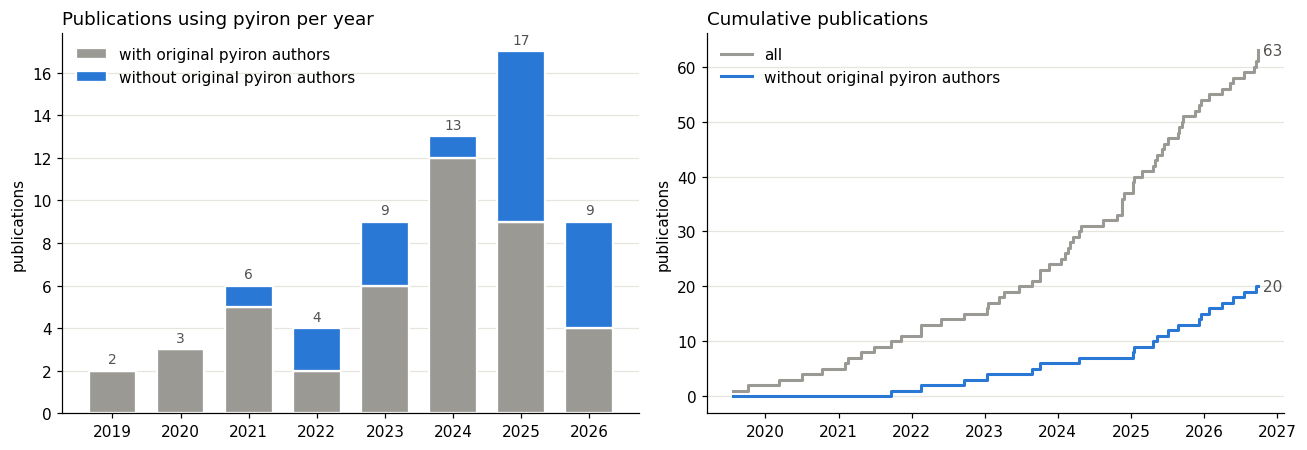

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
years = per_year.index
ax.bar(years, per_year["core"], color=GREY, width=0.7, label="with original pyiron authors",
       edgecolor="white", linewidth=1.5)
ax.bar(years, per_year["independent"], bottom=per_year["core"], color=BLUE, width=0.7,
       label="without original pyiron authors", edgecolor="white", linewidth=1.5)
for y, t in per_year["total"].items():
    ax.text(y, t + 0.2, str(t), ha="center", va="bottom", fontsize=9, color="#52514e")
ax.set_title("Publications using pyiron per year", loc="left")
ax.set_ylabel("publications")
ax.set_xticks(years)
ax.legend(frameon=False, loc="upper left")

ax = axes[1]
cum = df[~df.is_original].sort_values("date")
cum_all = range(1, len(cum) + 1)
cum_ind = (cum.category == "independent").cumsum()
ax.step(cum.date, list(cum_all), where="post", color=GREY, lw=2, label="all")
ax.step(cum.date, cum_ind, where="post", color=BLUE, lw=2, label="without original pyiron authors")
ax.text(cum.date.iloc[-1], len(cum), f" {len(cum)}", va="center", color="#52514e")
ax.text(cum.date.iloc[-1], cum_ind.iloc[-1], f" {cum_ind.iloc[-1]}", va="center", color="#52514e")
ax.set_title("Cumulative publications", loc="left")
ax.set_ylabel("publications")
ax.legend(frameon=False, loc="upper left")

fig.tight_layout()
plt.show()

*2026 is incomplete (data until the beginning of October).*

## Growth of the author community
For every year we count the authors who appear on a pyiron publication for the first time.
Core authors are excluded, so the curve measures how many *new* people publish with pyiron.

In [8]:
first_year = {}
for _, row in df.sort_values("date").iterrows():
    for k in row.author_keys:
        first_year.setdefault(k, (row.year, row.is_consortium))

authors_df = pd.DataFrame(
    [(k, display_name[k], y, c) for k, (y, c) in first_year.items() if k not in CORE],
    columns=["key", "name", "first_year", "via_consortium"],
)
new_authors = (
    authors_df.groupby(["first_year", "via_consortium"]).size().unstack(fill_value=0)
    .rename(columns={False: "regular papers", True: "consortium papers"})
    .reindex(columns=["regular papers", "consortium papers"], fill_value=0)
)
new_authors["cumulative"] = new_authors[["regular papers", "consortium papers"]].sum(axis=1).cumsum()
new_authors

via_consortium,regular papers,consortium papers,cumulative
first_year,,,
2019,11,0,11
2020,16,0,27
2021,24,0,51
2022,14,0,65
2023,31,0,96
2024,22,0,118
2025,46,82,246
2026,25,56,327


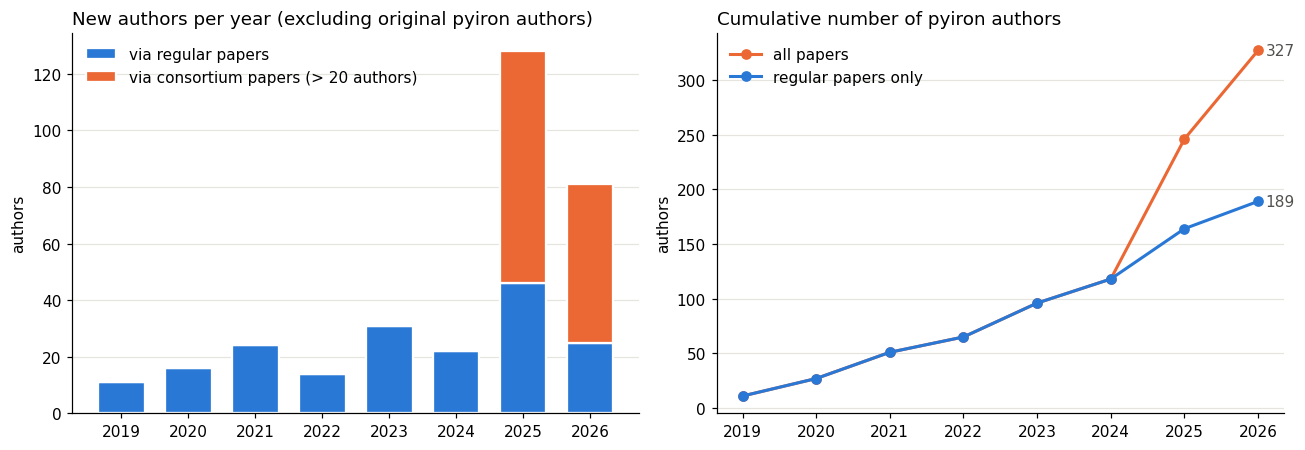

year,2019,2020,2021,2022,2023,2024,2025,2026
active authors,11,17,28,16,39,40,150,108


In [9]:
active = (
    df.explode("author_keys")
    .loc[lambda d: ~d.author_keys.isin(CORE)]
    .groupby("year").author_keys.nunique()
    .rename("active authors")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
ax.bar(new_authors.index, new_authors["regular papers"], color=BLUE, width=0.7,
       edgecolor="white", linewidth=1.5, label="via regular papers")
ax.bar(new_authors.index, new_authors["consortium papers"], bottom=new_authors["regular papers"],
       color=ORANGE, width=0.7, edgecolor="white", linewidth=1.5,
       label=f"via consortium papers (> {CONSORTIUM_SIZE} authors)")
ax.set_title("New authors per year (excluding original pyiron authors)", loc="left")
ax.set_ylabel("authors")
ax.set_xticks(new_authors.index)
ax.legend(frameon=False, loc="upper left")

ax = axes[1]
regular_cum = new_authors["regular papers"].cumsum()
ax.plot(new_authors.index, new_authors["cumulative"], color=ORANGE, lw=2, marker="o", ms=6,
        label="all papers")
ax.plot(new_authors.index, regular_cum, color=BLUE, lw=2, marker="o", ms=6,
        label="regular papers only")
for s in (new_authors["cumulative"], regular_cum):
    ax.text(s.index[-1] + 0.1, s.iloc[-1], str(s.iloc[-1]), va="center", color="#52514e")
ax.set_title("Cumulative number of pyiron authors", loc="left")
ax.set_ylabel("authors")
ax.set_xticks(new_authors.index)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()
active.to_frame().T

## Research groups
Papers are connected in a network when they share authors who are **not** core authors; the
edge weight is the number of shared non-core authors. Simply taking connected components of this
network chains most papers into one large cluster, because a few people (e.g. postdocs changing
institutes) bridge groups. Instead, groups are identified with Louvain community detection, which
splits the network at these weak bridges. Consortium papers (more than `CONSORTIUM_SIZE` authors)
are excluded, as they connect otherwise unrelated groups. Papers authored only by core authors form
their own group. Each group is labelled by its two most frequent non-core authors.

In [10]:
regular = df[~df.is_consortium & ~df.is_original]
G = nx.Graph()
G.add_nodes_from(regular.index)
author_to_papers = {}
for idx, ks in regular.author_keys.items():
    for k in ks:
        if k not in CORE:
            author_to_papers.setdefault(k, []).append(idx)
for papers in author_to_papers.values():
    for a, i in enumerate(papers):
        for j in papers[a + 1:]:
            w = G.get_edge_data(i, j, {"weight": 0})["weight"]
            G.add_edge(i, j, weight=w + 1)
print(f"connected components: {nx.number_connected_components(G)}, "
      f"largest: {len(max(nx.connected_components(G), key=len))} papers")

core_only = [i for i in regular.index if all(k in CORE for k in df.loc[i, "author_keys"])]
communities = [c for c in nx.community.louvain_communities(G, weight="weight", seed=1)
               if not set(c) <= set(core_only)] + [set(core_only)]


def group_label(paper_ids):
    counts = Counter(k for i in paper_ids for k in df.loc[i, "author_keys"] if k not in CORE)
    if not counts:
        return "original pyiron authors only"
    if len(paper_ids) == 1:
        # single paper: use the last (typically senior) non-core author
        last = [name_key(a) for a in df.loc[paper_ids[0], "authors"] if name_key(a) not in CORE][-1]
        return display_name[last]
    return " / ".join(display_name[k] for k, _ in counts.most_common(2))


groups = []
for comp in communities:
    ids = sorted(comp, key=lambda i: df.loc[i, "date"])
    sub = df.loc[ids]
    groups.append({
        "group": group_label(ids),
        "papers": len(ids),
        "first year": sub.year.min(),
        "last year": sub.year.max(),
        "with core authors": int((sub.category == "core").sum()),
        "independent": int((sub.category == "independent").sum()),
        "paper_ids": ids,
    })
groups_df = pd.DataFrame(groups).sort_values(["papers", "first year"], ascending=[False, True]).reset_index(drop=True)
for gid, ids in enumerate(groups_df.paper_ids):
    df.loc[ids, "group"] = groups_df.loc[gid, "group"]
print(f"{len(groups_df)} distinct groups in {len(regular)} regular publications")
groups_df.drop(columns="paper_ids")

connected components: 16, largest: 42 papers
18 distinct groups in 59 regular publications


,group,papers,first year,last year,with core authors,independent
0,Matous Mrovec / Sarath Menon,12,2019,2026,10,2
1,Liam Huber / David Holec,9,2020,2026,6,3
2,Danny Perez / Ping Yang,8,2023,2026,4,4
3,Christoph Freysoldt / Omkar Hegde,7,2020,2025,7,0
4,Blazej Grabowski / Fritz Körmann,6,2019,2024,5,1
5,original pyiron authors only,3,2021,2026,3,0
6,Edward F. Holby / Ivana Matanovic,3,2025,2026,0,3
7,Ilya M. Eremin,1,2021,2021,1,0
8,Masashi Ishii,1,2022,2022,0,1
9,Eduardo Mendive-Tapia,1,2022,2022,1,0


In [11]:
pd.set_option("display.max_colwidth", 90)
for _, g in groups_df[groups_df.papers > 1].iterrows():
    print(f"=== {g.group} ({g.papers} papers) ===")
    for i in g.paper_ids:
        print(f"  {df.loc[i, 'year']}  [{df.loc[i, 'category'][:4]}]  {df.loc[i, 'title'][:95]}")

=== Matous Mrovec / Sarath Menon (12 papers) ===
  2019  [core]  Phase transitions in titanium with an analytic bond-order potential
  2021  [core]  Performant implementation of the atomic cluster expansion (PACE) and application to copper and 
  2023  [core]  FitSNAP: Atomistic machine learning with LAMMPS
  2023  [core]  Atomic cluster expansion for a general-purpose interatomic potential of magnesium
  2024  [core]  Parametrization protocol and refinement strategies for accurate and transferable analytic bond-
  2024  [inde]  General purpose potential for glassy and crystalline phases of Cu-Zr alloys based on the ACE fo
  2024  [core]  mamonca: magnetic Monte Carlo code
  2024  [core]  Efficient Parametrization of Transferable Atomic Cluster Expansion for Water
  2024  [core]  From electrons to phase diagrams with machine learning potentials using pyiron based automated 
  2025  [inde]  Machine-learning interatomic potential for BaTiO3: phase transitions, domain walls, and grain b
 

### Groups publishing with pyiron over time
A group counts as *new* in the year of its first pyiron publication. A group is *independent*
if at least one of its papers has none of the original pyiron authors.

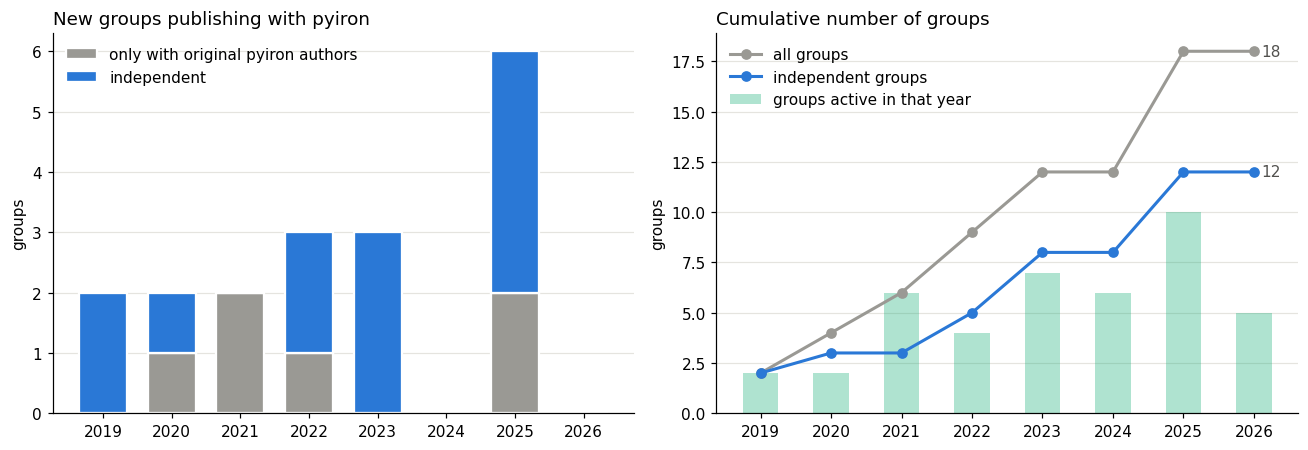

,with core authors only,independent,cumulative,active
first year,,,,
2019,0,2,2,2
2020,1,1,4,2
2021,2,0,6,6
2022,1,2,9,4
2023,0,3,12,7
2024,0,0,12,6
2025,2,4,18,10
2026,0,0,18,5


In [12]:
groups_df["independent group"] = groups_df["independent"] > 0
new_groups = (
    groups_df.groupby(["first year", "independent group"]).size().unstack(fill_value=0)
    .rename(columns={False: "with core authors only", True: "independent"})
    .reindex(columns=["with core authors only", "independent"], fill_value=0)
    .reindex(range(df.year.min(), df.year.max() + 1), fill_value=0)
)
active_groups = df[df.group.notna()].groupby("year").group.nunique().reindex(new_groups.index, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
ax.bar(new_groups.index, new_groups["with core authors only"], color=GREY, width=0.7,
       edgecolor="white", linewidth=1.5, label="only with original pyiron authors")
ax.bar(new_groups.index, new_groups["independent"], bottom=new_groups["with core authors only"],
       color=BLUE, width=0.7, edgecolor="white", linewidth=1.5, label="independent")
ax.set_title("New groups publishing with pyiron", loc="left")
ax.set_ylabel("groups")
ax.set_xticks(new_groups.index)
ax.legend(frameon=False, loc="upper left")

ax = axes[1]
cum_groups = new_groups.sum(axis=1).cumsum()
cum_ind_groups = new_groups["independent"].cumsum()
ax.plot(cum_groups.index, cum_groups, color=GREY, lw=2, marker="o", ms=6, label="all groups")
ax.plot(cum_ind_groups.index, cum_ind_groups, color=BLUE, lw=2, marker="o", ms=6, label="independent groups")
ax.bar(active_groups.index, active_groups, color=AQUA, width=0.5, alpha=0.35,
       label="groups active in that year")
for s in (cum_groups, cum_ind_groups):
    ax.text(s.index[-1] + 0.1, s.iloc[-1], str(s.iloc[-1]), va="center", color="#52514e")
ax.set_title("Cumulative number of groups", loc="left")
ax.set_ylabel("groups")
ax.set_xticks(cum_groups.index)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()
pd.concat([new_groups, cum_groups.rename("cumulative"), active_groups.rename("active")], axis=1)

### Co-authorship network
Each node is a publication (consortium papers excluded); edges connect papers sharing a non-core author.
Blue papers have none of the original pyiron authors.

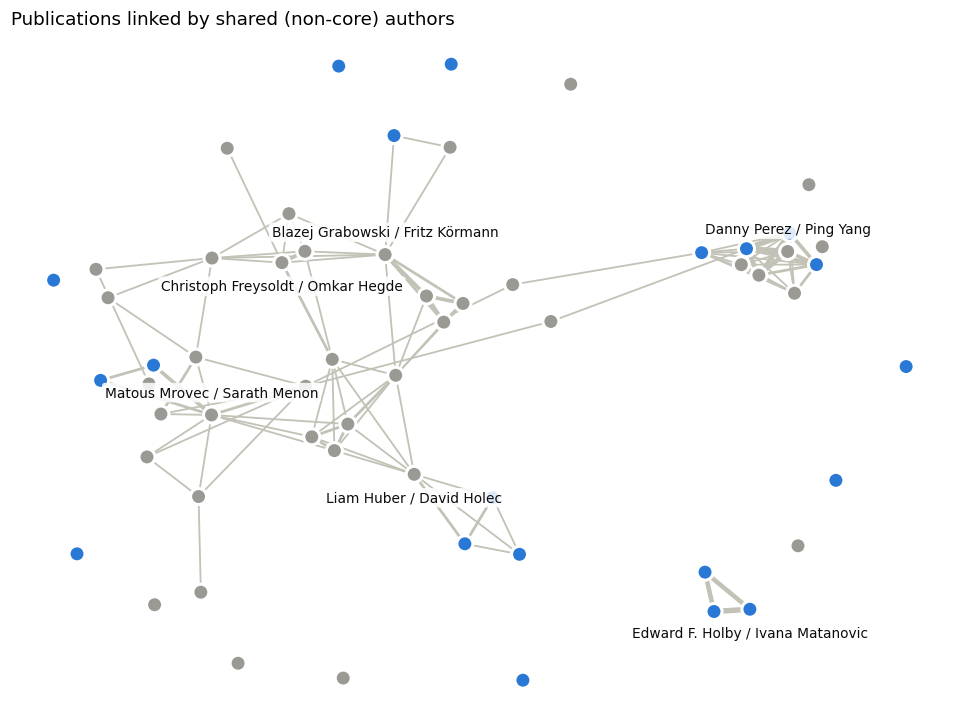

In [13]:
fig, ax = plt.subplots(figsize=(11, 8))
pos = nx.spring_layout(G, seed=3, k=0.45)
colors = [BLUE if df.loc[n, "category"] == "independent" else GREY for n in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#c3c2b7",
                       width=[0.6 + 0.6 * d["weight"] for *_, d in G.edges(data=True)])
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=110, edgecolors="white", linewidths=2)
for n, (_, g) in enumerate(groups_df[(groups_df.papers >= 3) & (groups_df.group != "original pyiron authors only")].iterrows()):
    # label the best-connected paper within the group
    hub = max(g.paper_ids, key=lambda i: G.subgraph(g.paper_ids).degree(i, weight="weight"))
    x, y = pos[hub]
    ax.annotate(g.group, (x, y), xytext=(0, 12 if n % 2 == 0 else -18), textcoords="offset points", ha="center",
                fontsize=9, color="#0b0b0b",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))
ax.set_axis_off()
ax.set_title("Publications linked by shared (non-core) authors", loc="left")
plt.show()

## Publishers

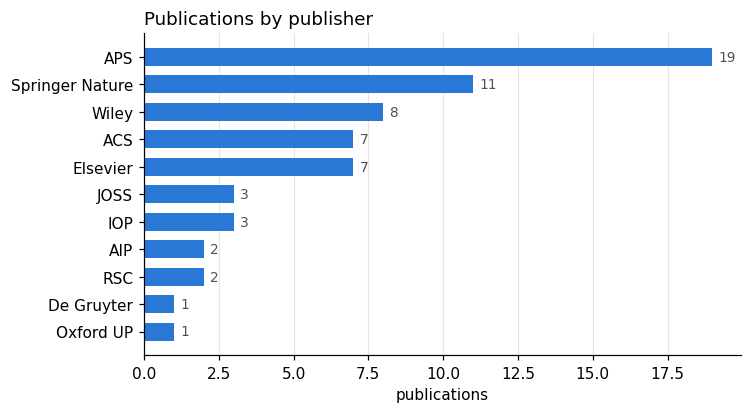

In [14]:
PUBLISHERS = {
    "10.1103": "APS", "10.1038": "Springer Nature", "10.1016": "Elsevier", "10.1021": "ACS",
    "10.1002": "Wiley", "10.1063": "AIP", "10.1088": "IOP", "10.21105": "JOSS", "10.1039": "RSC",
    "10.1515": "De Gruyter", "10.1093": "Oxford UP",
}


def publisher(link):
    if "sciencedirect" in link:
        return "Elsevier"
    m = re.search(r"10\.\d{4,5}", link)
    return PUBLISHERS.get(m.group(0), "other") if m else "other"


df["publisher"] = df.doi.apply(publisher)
pub = df.publisher.value_counts().sort_values()
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(pub.index, pub.values, color=BLUE, height=0.65)
for i, v in enumerate(pub.values):
    ax.text(v + 0.2, i, str(v), va="center", fontsize=9, color="#52514e")
ax.grid(axis="x", color="#e5e4df")
ax.grid(axis="y", visible=False)
ax.set_title("Publications by publisher", loc="left")
ax.set_xlabel("publications")
plt.show()

## Summary

In [15]:
pre = df[~df.is_original]
first, last_full = df.year.min() + 1, df.year.max() - 1
summary = {
    "publications (excluding original paper)": len(pre),
    "publications without original pyiron authors": int((pre.category == "independent").sum()),
    "unique authors (excluding original pyiron authors)": len(authors_df),
    "  of which only on consortium papers": int(authors_df.via_consortium.sum()),
    "distinct groups": len(groups_df),
    "  of which independent of the original authors": int(groups_df["independent group"].sum()),
    f"publications {first}-{first + 2}": int(pre[pre.year.between(first, first + 2)].shape[0]),
    f"publications {last_full - 2}-{last_full}": int(pre[pre.year.between(last_full - 2, last_full)].shape[0]),
    f"share without original authors {first}-{first + 2}":
        round((pre[pre.year.between(first, first + 2)].category == "independent").mean(), 2),
    f"share without original authors {last_full - 2}-{last_full}":
        round((pre[pre.year.between(last_full - 2, last_full)].category == "independent").mean(), 2),
}
pd.Series(summary, name="value", dtype=object).to_frame()

,value
publications (excluding original paper),63
publications without original pyiron authors,20
unique authors (excluding original pyiron authors),327
of which only on consortium papers,138
distinct groups,18
of which independent of the original authors,12
publications 2020-2022,13
publications 2023-2025,39
share without original authors 2020-2022,0.23
share without original authors 2023-2025,0.31
